# U-Net Breast Thermography Segmentation
 
**Dataset:** Rodriguez-Guerrero Breast Thermography — 3D Reconstruction subset  
**Task:** Binary segmentation of breast region from multi-view thermal TIFF images  
**Architecture:** U-Net (encoder–decoder with skip connections)  
**Framework:** PyTorch
 
---
 
## Phase 1: Data Loading
 
Converts raw temperature matrices (TIFF) to normalized $256 \times 256$ tensors, paired with PNG ground-truth masks.

In [3]:
%pip install torch torchvision tifffile

Note: you may need to restart the kernel to use updated packages.


### 1.1 — Dataset Initialization (`ThermalDatasetV2`)
 
Pairs each PNG mask with its corresponding TIFF using a prefix-based fuzzy match to handle degree-symbol encoding differences in filenames (e.g., `90°`).

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import tifffile as tiff
import cv2
import numpy as np
import os
import glob
import random
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

class ThermalDatasetV2(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} total manual masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search (Fuzzy Match for Degree Symbols)
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1)
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)
        
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask (Robust Read for Windows Unicode compatibility)
        mask_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(mask_array, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            raise ValueError(f"CRITICAL: Could not read mask {os.path.basename(mask_path)}. File may be corrupted or empty.")
            
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # 5. Convert to Tensors (C, H, W)
        img_tensor = torch.from_numpy(img_256).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask_256).unsqueeze(0)

        # --- V2 SYNCHRONIZED AUGMENTATION ---
        # 50% chance to flip horizontally 
        if random.random() > 0.5:
            img_tensor = TF.hflip(img_tensor)
            mask_tensor = TF.hflip(mask_tensor)

        # Random rotation between -10 and +10 degrees 
        angle = random.uniform(-10, 10)
        img_tensor = TF.rotate(img_tensor, angle)
        mask_tensor = TF.rotate(mask_tensor, angle)

        return img_tensor, mask_tensor

# --- PATHS AND INITIALIZATION ---
TIFF_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\organized_by_patient"
MASK_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\GroundTruth_Masks"

# Load the full augmented dataset
full_dataset = ThermalDatasetV2(TIFF_BASE, MASK_BASE)

# --- 80/20 DATASET SPLIT ---
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create the loaders (Batch size 2 as prescribed)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

print(f"Data Prep Complete: {len(train_dataset)} images for Training, {len(val_dataset)} images for Validation.")

Dataset initialized with 162 total manual masks.
Data Prep Complete: 129 images for Training, 33 images for Validation.


---
 
## Phase 2: Model Architecture
 
### 2.1 — U-Net Architecture
 
A 3-level encoder–decoder U-Net with skip connections:
 
| Stage        | Channels      |
|--------------|--------------|
| Encoder 1    | 1 → 64       |
| Encoder 2    | 64 → 128     |
| Encoder 3    | 128 → 256    |
| Bottleneck   | 256 → 512    |
| Decoder 3    | 512 → 256    |
| Decoder 2    | 256 → 128    |
| Decoder 1    | 128 → 64     |
| Output       | 64 → 1 (sigmoid) |
 
Each conv block uses two `Conv2d(3×3) → ReLU` operations.

In [13]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c, dropout_rate=0.2):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c), # Added: Stabilizes learning
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout_rate), # Added: Prevents overfitting
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        # Output
        self.out     = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        b  = self.bottleneck(nn.MaxPool2d(2)(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.sigmoid(self.out(d1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet().to(device)
print(f"Model ready on: {device}")


Model ready on: cpu


---
 
### 2.2 — Training: Adam Optimizer + BCE Loss
 
- **Loss:** Binary Cross-Entropy (`BCELoss`)
- **Optimizer:** Adam, $lr = 1 \times 10^{-4}$
- **Epochs:** 100
- **Batch size:** 2
 
Progress is reported every 10 epochs. Final weights are saved to disk upon completion.

In [9]:
%pip install tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.


Training loop with early stopping based on validation loss.

In [10]:
# ==========================================
# 1. ARCHITECTURE: V2 U-Net 
# ==========================================
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c, dropout_rate=0.2):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),       # Stabilizes learning gradients
                nn.ReLU(inplace=True),
                nn.Dropout2d(dropout_rate),  # Prevents overfitting to the small dataset
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512, dropout_rate=0.3) # Higher dropout at bottleneck

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.out     = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        b  = self.bottleneck(nn.MaxPool2d(2)(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.sigmoid(self.out(d1))

# ==========================================
# 2. CUSTOM LOSS: BCE + Dice
# ==========================================
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        smooth = 1e-6
        intersection = (pred * target).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return bce_loss + dice_loss

# ==========================================
# 3. UTILITY: Early Stopping
# ==========================================
class EarlyStopping:
    def __init__(self, patience=12, min_delta=0, save_path='breast_segmentation_unet_v2_best.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        print(f'Validation loss decreased to {val_loss:.6f}. Saving model...')
        torch.save(model.state_dict(), self.save_path)

# ==========================================
# 4. V2 TRAINING LOOP
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)

criterion = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
early_stopper = EarlyStopping(patience=12, save_path="breast_segmentation_unet_v2_best.pth")

num_epochs = 100
print(f"Starting V2 Training on {device}...")

for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for imgs, masks in train_bar:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            output = model(imgs)
            loss = criterion(output, masks)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- EARLY STOP CHECK ---
    early_stopper(avg_val_loss, model)
    if early_stopper.early_stop:
        print(f"!!! Early stopping triggered at epoch {epoch+1}. Training halted.")
        break

print("Training session finalized.")

Starting V2 Training on cpu...


Epoch 1/100 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

KeyboardInterrupt: 

#### Manual Checkpoint Save
 
Run this cell independently to save the current model weights (e.g., after early stopping).

In [ ]:
torch.save(model.state_dict(), "breast_segmentation_unet_v1_60epochs.pth")
print("Weights saved successfully!")


---
 
### 2.3 — Prediction Visualization
 
Displays a side-by-side comparison of the input thermal image, the ground-truth mask, and the U-Net prediction for one sample from the training loader.

In [5]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


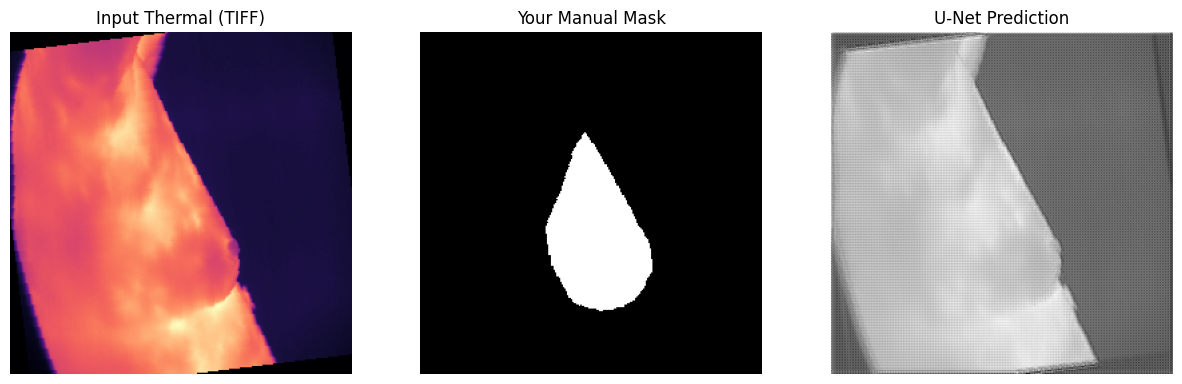

In [54]:
import matplotlib.pyplot as plt
import random

model.eval()
with torch.no_grad():
    # Grab a batch from the loader
    imgs, masks = next(iter(train_loader))
    imgs = imgs.to(device)

    # Predict
    preds = model(imgs)

    # Plot first item in batch
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(imgs[0, 0].cpu(), cmap='magma')
    axs[0].set_title("Input Thermal (TIFF)")
    axs[1].imshow(masks[0, 0].cpu(), cmap='gray')
    axs[1].set_title("Your Manual Mask")
    axs[2].imshow(preds[0, 0].cpu(), cmap='gray')
    axs[2].set_title("U-Net Prediction")
    for ax in axs:
        ax.axis('off')
    plt.show()


---
 
## Phase 2 — Inference Pipeline
 
### Automated Segmentation & Edge Extraction
 
Runs the trained model over the entire TIFF dataset. For each image:
1. Normalizes the raw temperature matrix (Paper Eq 1)
2. Feeds it through the U-Net
3. Binarizes the output at threshold 0.5 (Suzuki binarization)
4. Retains the largest connected contour to remove noise
5. Extracts the breast boundary with Canny edge detection
6. Saves the edge map as `<original_name>_edge.png` mirroring the source folder structure

In [11]:
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges"


In [18]:
import torch
import os
import glob
import tifffile as tiff
import cv2
import numpy as np
from tqdm.notebook import tqdm

def automated_segmentation(model_path, tiff_dir, output_dir):
    # Load the trained model inside the function
    model = UNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Find all original TIFFs
    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")

    for f_path in tqdm(all_tiffs):
        try:
            # 1. Load and Preprocess per paper Eq 1 [cite: 113, 115]
            raw = tiff.imread(f_path)
            t_min, t_max = np.min(raw), np.max(raw)
            norm = (raw - t_min) / (t_max - t_min + 1e-8)
            img_256 = cv2.resize(norm.astype(np.float32), (256, 256))

            # 2. U-Net Prediction [cite: 131]
            img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                pred = model(img_tensor).squeeze().cpu().numpy()

            # 3. Suzuki/Binarization Filtering
            binary = (pred > 0.5).astype(np.uint8) * 255

            # 4. Retain Largest Area
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            clean_mask = np.zeros_like(binary)
            if contours:
                largest = max(contours, key=cv2.contourArea)
                cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)

            # 5. Canny Edge Extraction
            edges = cv2.Canny(clean_mask, 100, 200)

            # Save the finalized edge map
            rel_path = os.path.relpath(f_path, tiff_dir)
            out_name = os.path.splitext(rel_path)[0] + "_edge.png"
            save_path = os.path.join(output_dir, out_name)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            cv2.imwrite(save_path, edges)
        except Exception as e:
            print(f"Failed to process {f_path}: {e}")

# Example usage (ensure these variables are defined in previous cells):
model_weights = "breast_segmentation_unet_v2_best.pth"
automated_segmentation(model_weights, TIFF_BASE, output_edges)

Running automated segmentation on 657 images...


  0%|          | 0/657 [00:00<?, ?it/s]

---
 
### Visualizing the Generated Edge Overlays
 
Randomly samples `n` edge maps and overlays them (green) on the original thermal image rendered with the Magma colormap. Uses `robust_read_image` to bypass Windows Unicode path issues and skip zero-byte (interrupted) files.

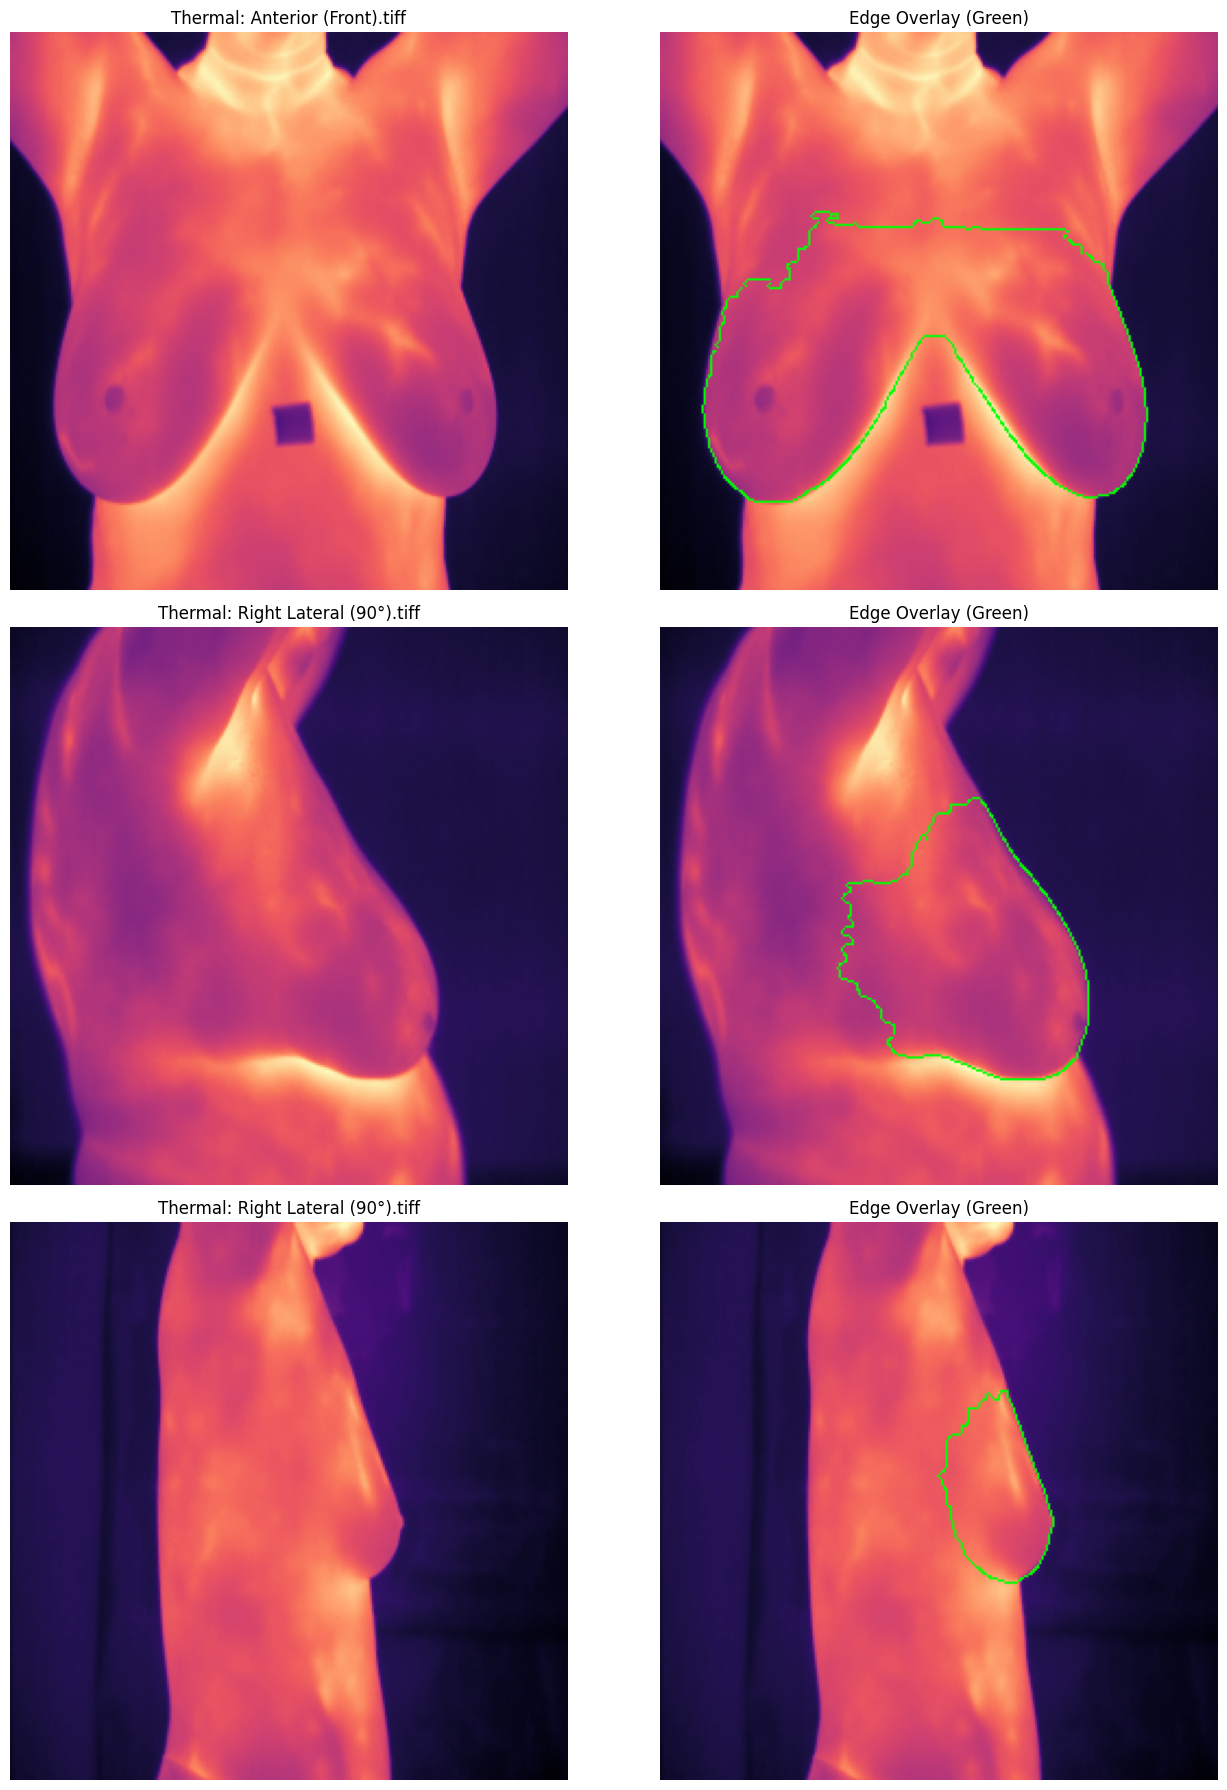

In [22]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0:  # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None


def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)

    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)

        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue

        # 3. Find corresponding TIFF using Prefix Matching
        rel_path         = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename    = os.path.basename(rel_path)
        search_folder    = os.path.join(tiff_dir, patient_subfolder)
        search_prefix    = edge_filename.split('(')[0].strip()

        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)

        if tiff_path is None:
            continue

        # 4. Load/Normalize TIFF and Resize to 256x256
        raw      = tiff.imread(tiff_path)
        norm     = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)

        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0]

        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)


---
 
## Phase 3: Key Point Extraction ($P_1$, $P_2$, $P_3$)
 
### Step 3.1 — Anchor Point Extraction
 
Extracts three geometric anchor points from the binary edge map per view:
 
| Point | Description |
|-------|-------------|
| $P_1$ | Leftmost point in the lower breast half (far right in image space) |
| $P_2$ | Lowest point (nipple region / breast apex) |
| $P_3$ | Rightmost point in the lower breast half (far left in image space) |
 
The top 30% of the image is zeroed out to suppress neck/shoulder artefacts.

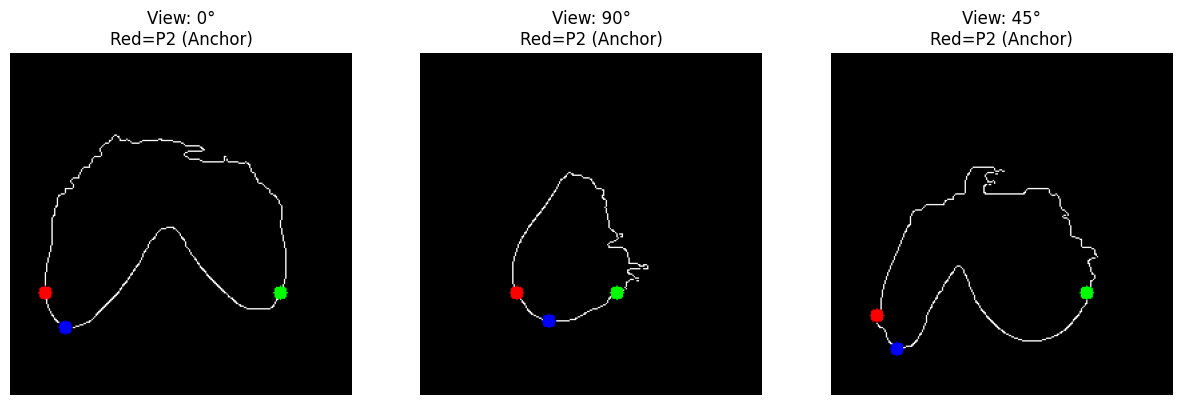

In [53]:
def extract_anchors_v2(edge_map, view_angle):
    # Ignore the top 30% of the image to remove neck/shoulder noise
    h, w = edge_map.shape
    edge_map[:int(h * 0.7), :] = 0

    coords = np.column_stack(np.where(edge_map > 0))
    if len(coords) < 10:
        return None

    # Focus P2 on the lowest 20% of the remaining ROI
    p2 = coords[np.argmax(coords[:, 0])]  # Strictly the lowest pixel

    # For P1 and P3, find the widest points in the lower half
    lower_half = coords[coords[:, 0] > (h * 0.5)]
    p1 = lower_half[np.argmin(lower_half[:, 1])]  # Far right
    p3 = lower_half[np.argmax(lower_half[:, 1])]  # Far left

    return {"P1": p1, "P2": p2, "P3": p3}


def test_coordinate_extraction(edge_dir, patient_id="Patient_106"):
    # Find all edge maps for a specific patient
    patient_path = os.path.join(edge_dir, patient_id)
    edge_files   = glob.glob(os.path.join(patient_path, "**", "*.png"), recursive=True)

    if not edge_files:
        print(f"No edges found for {patient_id}. Did you generate them?")
        return

    plt.figure(figsize=(15, 5))
    for i, f_path in enumerate(edge_files[:3]):  # Test first 3 views
        # Determine angle from filename
        angle = 0
        if "90" in f_path:  angle = 90
        elif "45" in f_path: angle = 45

        anchors = extract_anchors(f_path, angle)
        if not anchors:
            continue

        # Load for display
        img = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_COLOR)

        # Draw the points: P1(Blue), P2(Red), P3(Green)
        cv2.circle(img, (anchors["P1"][1], anchors["P1"][0]), 5, (255, 0, 0), -1)
        cv2.circle(img, (anchors["P2"][1], anchors["P2"][0]), 5, (0, 0, 255), -1)
        cv2.circle(img, (anchors["P3"][1], anchors["P3"][0]), 5, (0, 255, 0), -1)

        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(f"View: {angle}°\nRed=P2 (Anchor)")
        plt.axis('off')

    plt.show()


# Run the test on a patient you already generated
test_coordinate_extraction(output_edges, patient_id="Patient_113")


In [51]:
def extract_anchors(edge_path, view_angle):
    # Load edge map
    edge_map = cv2.imdecode(np.fromfile(edge_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    if edge_map is None:
        return None
    # Ignore the top 30% of the image to remove neck/shoulder noise
    h, w = edge_map.shape
    edge_map[:int(h * 0.7), :] = 0
    coords = np.column_stack(np.where(edge_map > 0))
    if len(coords) < 10:
        return None
    # Focus P2 on the lowest 20% of the remaining ROI
    p2 = coords[np.argmax(coords[:, 0])]  # Strictly the lowest pixel
    # For P1 and P3, find the widest points in the lower half
    lower_half = coords[coords[:, 0] > (h * 0.5)]
    p1 = lower_half[np.argmin(lower_half[:, 1])]  # Far right
    p3 = lower_half[np.argmax(lower_half[:, 1])]  # Far left
    return {"P1": p1, "P2": p2, "P3": p3}
